# Effect of Antenna Bearing Angles on PDSCH BER over CDL Channels

This notebook studies the impact of transmit and receive antenna bearing angles on the bit error rate (BER) of a 5G NR PDSCH link-level simulation.

For each CDL channel profile, the simulation sweeps either the TX or RX bearing angle while keeping the other side fixed. The BER results are compared across multiple random seeds to illustrate how antenna orientation and CDL channel conditions affect PDSCH performance.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

from neoradium import CdlChannel, Carrier, PDSCH, AntennaPanel, AntennaElement, Grid, random

In [2]:
# A multipurpose function for calculating BER with different configurations
def getBitrateInfo(numSlots, snrDbs, pdsc, cdlProfile, txAlphas, rxAlphas, seed, rxOmni=False, quiet=False):
    results = {}                # Dictionary for storing the results
    for snrDb in snrDbs:
        random.setSeed(seed)    # Make the results reproducible
        t0 = time.monotonic()
        results[snrDb]={}
    
        for txAlpha in txAlphas:
            results[snrDb][txAlpha] = {}
            for rxAlpha in rxAlphas:
                
                # Create a CDL channel model
                rxAntenna = AntennaElement(beamWidth=[60,360]) if rxOmni else AntennaPanel([1,2])
                channel = CdlChannel(bwp, cdlProfile, delaySpread=300, carrierFreq=4e9, dopplerShift=5,
                                     txAntenna = AntennaPanel([2,4]),       # 8 TX antenna elements
                                     txOrientation = [txAlpha,0,0],
                                     rxAntenna = rxAntenna,   
                                     rxOrientation = [rxAlpha,0,0],
                                     seed = seed)
                bitErrors = 0
                totalBits = 0

                # Use the same channel for numSlots transmissions with different data bits
                for slotNo in range(numSlots):
                    pdsch.initGrid()                             # Create and initialize the internal PDSCH grid
                    numBits = pdsch.getBitCapacity()[0]          # Number of bits available in the PDSCH grid
                    txBits = random.bits(numBits)                # Generate random binary data
                    pdsch.setPdschData(txBits)                   # Map the bitstream to the resource elements
        
                    channelMatrix = channel.getChannelMatrix()              # Get the channel matrix
                    precoder = pdsch.getPrecodingMatrix(channelMatrix)      # Get the precoding matrix

                    txGrid = bwp.createGrid(channel.nrNt[1])                # Create the transmit resource grid
                    pdsch.precodeTo(txGrid, precoder)                       # Precode the PDSCH into txGrid
        
                    rxGrid = txGrid.applyChannel(channelMatrix)             # Apply the channel in the frequency domain
                    rxGrid = rxGrid.addNoise(snrDb=snrDb)                   # Add noise
        
                    effChanMat = channelMatrix @ precoder[None,...]         # Effective channel matrix
        
                    eqGrid, llrScales = pdsch.equalize(rxGrid, effChanMat)  # Equalization
                    rxBits = pdsch.getHardBits(eqGrid)[0]                   # Demodulation
                    bitErrors += np.abs(rxBits-txBits).sum()                # Calculate the number of bit errors
                    totalBits += numBits
        
                dt = time.monotonic()-t0                                    # Total runtime for this SNR
                results[snrDb][txAlpha][rxAlpha] = {"totalBits":totalBits, 
                                                    "bitErrors":bitErrors, 
                                                    "BER":      bitErrors*100/totalBits,
                                                    "Time":     dt}

    return results


## Different TX Bearing Angles

Running with seed 12 for CDL-A ...
Running with seed 123 for CDL-A ...
Running with seed 1234 for CDL-A ...
Running with seed 12345 for CDL-A ...


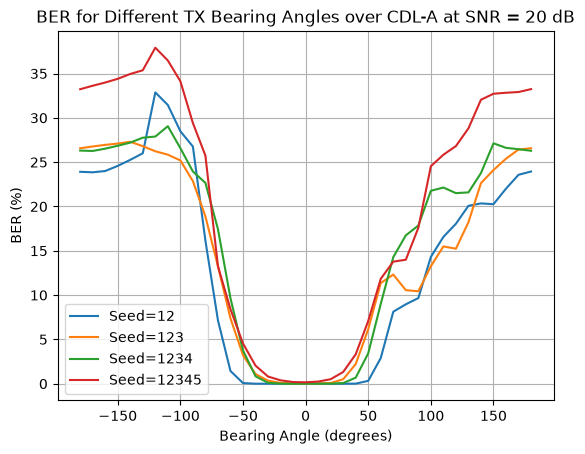


Running with seed 12 for CDL-B ...
Running with seed 123 for CDL-B ...
Running with seed 1234 for CDL-B ...
Running with seed 12345 for CDL-B ...


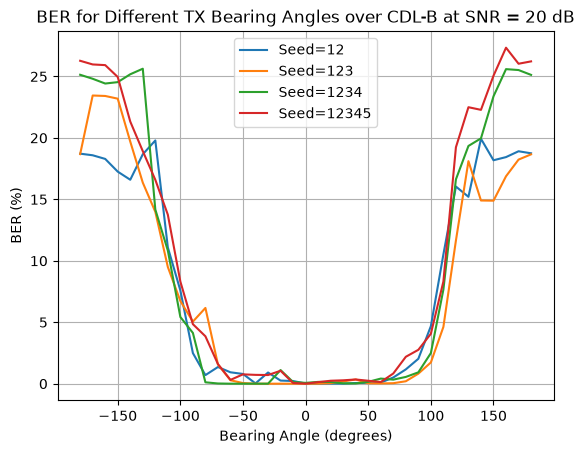


Running with seed 12 for CDL-C ...
Running with seed 123 for CDL-C ...
Running with seed 1234 for CDL-C ...
Running with seed 12345 for CDL-C ...


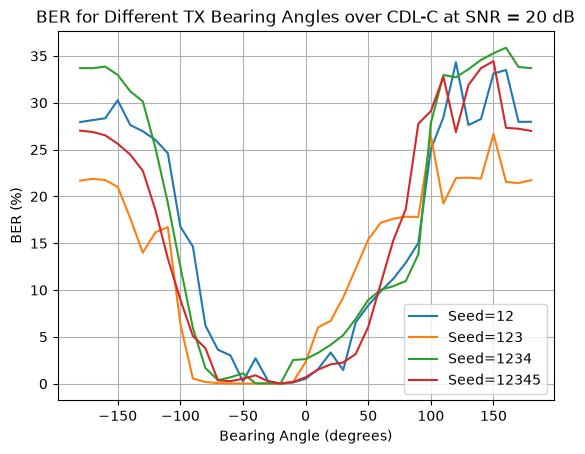


Running with seed 12 for CDL-D ...
Running with seed 123 for CDL-D ...
Running with seed 1234 for CDL-D ...
Running with seed 12345 for CDL-D ...


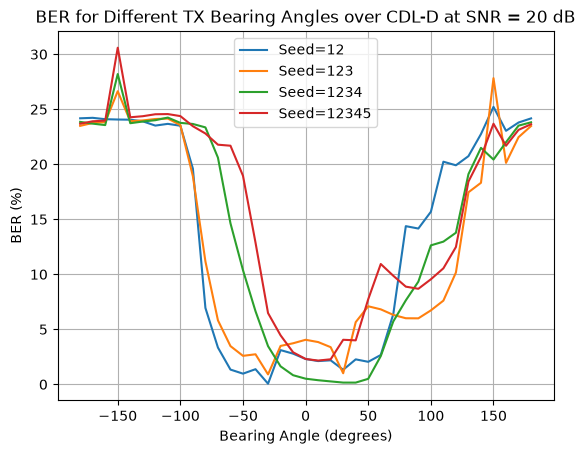


Running with seed 12 for CDL-E ...
Running with seed 123 for CDL-E ...
Running with seed 1234 for CDL-E ...
Running with seed 12345 for CDL-E ...


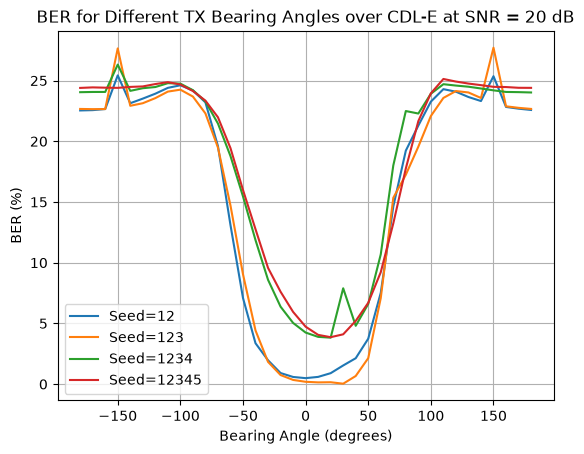

In [3]:
carrier = Carrier(numRbs=24, spacing=30)    # Carrier with 24 resource blocks and 30 kHz subcarrier spacing
bwp = carrier.curBwp                        # The only bandwidth part in the carrier

pdsch = PDSCH(bwp, numLayers=2, modulation="16QAM") # Create a PDSCH object
pdsch.setDMRS(configType=2, additionalPos=2)        # DMRS configuration

txAlphas=range(-180,181,10)
rxAlphas=[180]

snrDb=20
seeds = [12, 123, 1234, 12345]
allResults = {}
for cdl in ["A", "B", "C", "D", "E"]:
    for seed in seeds:
        print(f"Running with seed {seed} for CDL-{cdl} ...")
        allResults[seed] = getBitrateInfo(numSlots=50, snrDbs=[snrDb], pdsc=pdsch, cdlProfile=cdl, 
                                          txAlphas=txAlphas, rxAlphas=rxAlphas, seed=seed, quiet=True)

        if len(rxAlphas)==1:   bers = [allResults[seed][snrDb][txAlpha][rxAlphas[0]]["BER"] for txAlpha in txAlphas]
        else:                  bers = [allResults[seed][snrDb][txAlphas[0]][rxAlpha]["BER"] for rxAlpha in rxAlphas]
        plt.plot(range(-180,181,10), bers, label=f"Seed={seed}")
    
    plt.title(f"BER for Different {'TX' if len(rxAlphas) == 1 else 'RX'} Bearing Angles over CDL-{cdl} at SNR = {snrDb} dB")
    plt.grid()
    plt.legend()
    plt.xlabel("Bearing Angle (degrees)")
    plt.ylabel("BER (%)")
    plt.show()
    print()


## Different RX Bearing Angles

Running with seed 56 for CDL-A ...
Running with seed 567 for CDL-A ...
Running with seed 5678 for CDL-A ...
Running with seed 56789 for CDL-A ...


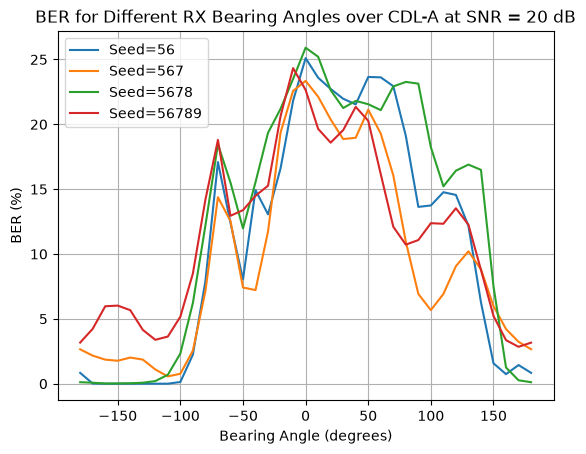

Running with seed 56 for CDL-B ...
Running with seed 567 for CDL-B ...
Running with seed 5678 for CDL-B ...
Running with seed 56789 for CDL-B ...


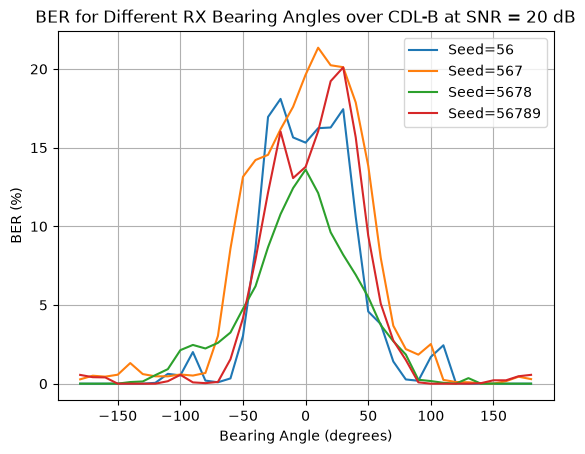

Running with seed 56 for CDL-C ...
Running with seed 567 for CDL-C ...
Running with seed 5678 for CDL-C ...
Running with seed 56789 for CDL-C ...


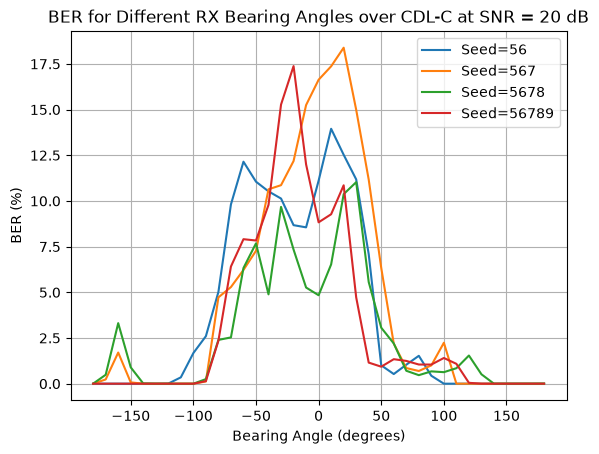

Running with seed 56 for CDL-D ...
Running with seed 567 for CDL-D ...
Running with seed 5678 for CDL-D ...
Running with seed 56789 for CDL-D ...


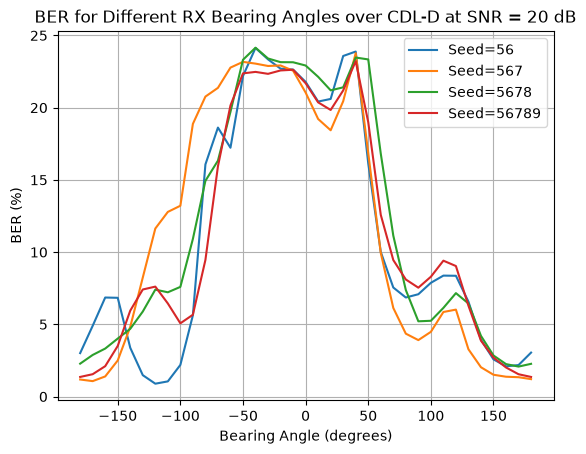

Running with seed 56 for CDL-E ...
Running with seed 567 for CDL-E ...
Running with seed 5678 for CDL-E ...
Running with seed 56789 for CDL-E ...


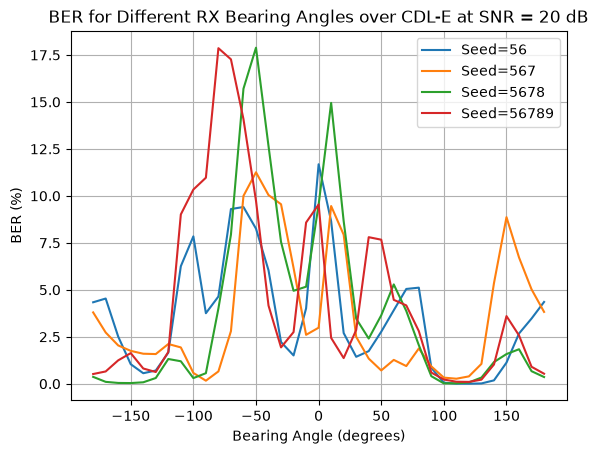

In [4]:
txAlphas=[0]
rxAlphas=range(-180,181,10)

snrDb=20
seeds = [56, 567, 5678, 56789]
allResults = {}
for cdl in ["A", "B", "C", "D", "E"]:
    for seed in seeds:
        print(f"Running with seed {seed} for CDL-{cdl} ...")
        allResults[seed] = getBitrateInfo(numSlots=50, snrDbs=[snrDb], pdsc=pdsch, cdlProfile=cdl,
                                          txAlphas=txAlphas, rxAlphas=rxAlphas, seed=seed, quiet=True)

        if len(rxAlphas)==1:   bers = [allResults[seed][snrDb][txAlpha][rxAlphas[0]]["BER"] for txAlpha in txAlphas]
        else:                  bers = [allResults[seed][snrDb][txAlphas[0]][rxAlpha]["BER"] for rxAlpha in rxAlphas]
        plt.plot(range(-180,181,10), bers, label=f"Seed={seed}")
    
    plt.title(f"BER for Different {'TX' if len(rxAlphas) == 1 else 'RX'} Bearing Angles over CDL-{cdl} at SNR = {snrDb} dB")
    plt.grid()
    plt.legend()
    plt.xlabel("Bearing Angle (degrees)")
    plt.ylabel("BER (%)")
    plt.show()

## TX Bearing Angles in MISO with an Omnidirectional RX Antenna

Running with seed 12 for CDL-A ...
Running with seed 123 for CDL-A ...
Running with seed 1234 for CDL-A ...
Running with seed 12345 for CDL-A ...


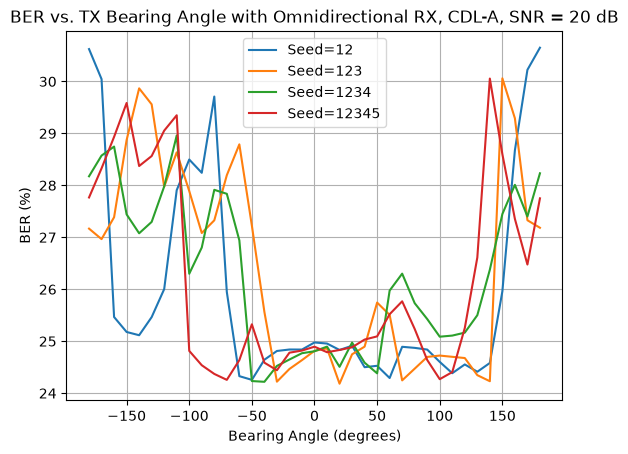

Running with seed 12 for CDL-B ...
Running with seed 123 for CDL-B ...
Running with seed 1234 for CDL-B ...
Running with seed 12345 for CDL-B ...


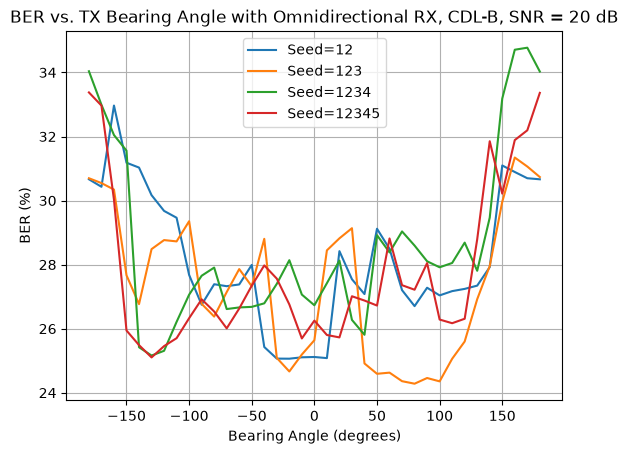

Running with seed 12 for CDL-C ...
Running with seed 123 for CDL-C ...
Running with seed 1234 for CDL-C ...
Running with seed 12345 for CDL-C ...


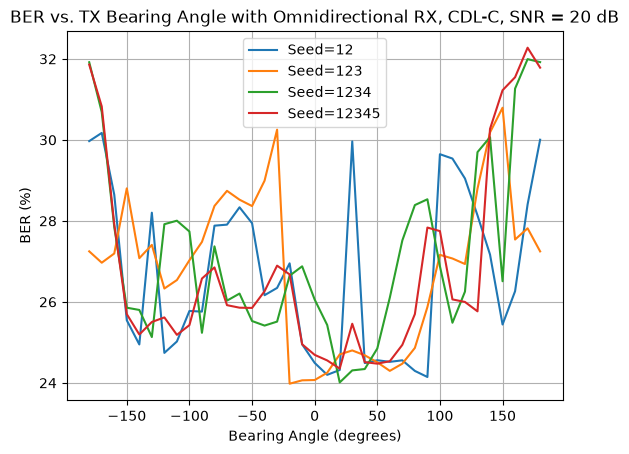

Running with seed 12 for CDL-D ...
Running with seed 123 for CDL-D ...
Running with seed 1234 for CDL-D ...
Running with seed 12345 for CDL-D ...


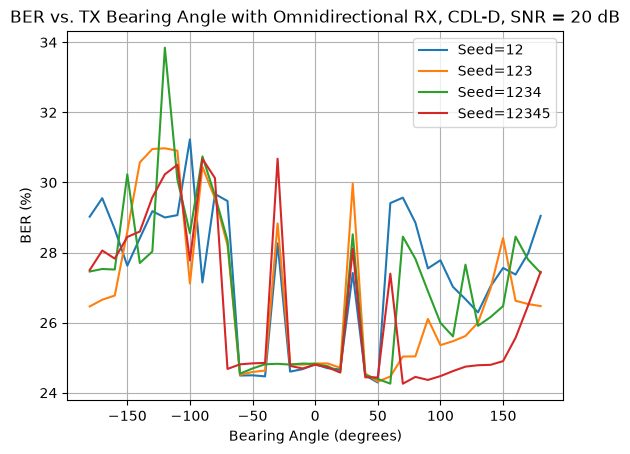

Running with seed 12 for CDL-E ...
Running with seed 123 for CDL-E ...
Running with seed 1234 for CDL-E ...
Running with seed 12345 for CDL-E ...


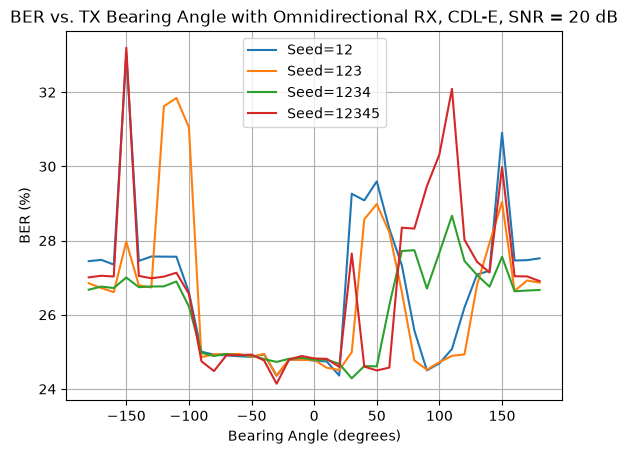

In [5]:
# Create the carrier:
carrier = Carrier(numRbs=24, spacing=30)    # Carrier with 14 resource blocks and 30 kHz subcarrier spacing
bwp = carrier.curBwp                        # The only bandwidth part in the carrier

# Create a PDSCH object
pdsch = PDSCH(bwp, numLayers=2, modulation="16QAM")
pdsch.setDMRS(configType=2, additionalPos=2)     # Specify the DMRS configuration

txAlphas=range(-180,181,10)
rxAlphas=[0]

snrDb=20
seeds = [12, 123, 1234, 12345]
allResults = {}
for cdl in ["A", "B", "C", "D", "E"]:
    for seed in seeds:
        print(f"Running with seed {seed} for CDL-{cdl} ...")
        allResults[seed] = getBitrateInfo(numSlots=50, snrDbs=[snrDb], pdsc=pdsch, cdlProfile=cdl, 
                                          txAlphas=txAlphas, rxAlphas=rxAlphas, 
                                          seed=seed, rxOmni=True, quiet=True)

        if len(rxAlphas)==1:   bers = [allResults[seed][snrDb][txAlpha][rxAlphas[0]]["BER"] for txAlpha in txAlphas]
        else:                  bers = [allResults[seed][snrDb][txAlphas[0]][rxAlpha]["BER"] for rxAlpha in rxAlphas]
        plt.plot(range(-180,181,10), bers, label=f"Seed={seed}")
    
    plt.title(f"BER vs. TX Bearing Angle with Omnidirectional RX, CDL-{cdl}, SNR = {snrDb} dB")
    plt.grid()
    plt.legend()
    plt.xlabel("Bearing Angle (degrees)")
    plt.ylabel("BER (%)")
    plt.show()